# Разведочный анализ данных о прокатах в Сеуле

Имеем датасет с информацией об аренде велосипедов в г.Сеул за определенный период. Задача данного анализа состоит в том, чтобы изучить особенности поведения рынка в различные периоды времени/сезоны, выявить лишнюю информацию, и подготовить данные для обучения предсказательной модели.  
  
Разрабатываемая модель поможет оптимизировать работу прокатов, спрогнознировать нагрузку, чтобы определить необходимое кол-во сотрудников(поддержка, кассиры, механики) в разное рабочее время.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv("SeoulBikeData.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(C)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

## Анализ столбцов и очистка данных

Видим большое кол-во различных столбцов. Рассмотрим, что имеем: 

    - Наш целевой столбец - Rented Bike Count(Кол-во арендованных за это время байков);
    - Date - Дата в формате dd.mm.yyyy(текст);
    - Hour - Час из расчета от 0 до 24, целочисленный;
    - Temperature(C) - Температура в градусах Цельсия в данный час;
    - Humidity(%) - Влажность воздуха;
    - Wind speed (m/s) - Скорость ветра;
    - Visibility (10m) - Видимость, однако в таблице не условная единица размером в десяток метров, как выяснилось, это высота установки прибора, 2000 здесь означает именно 2000 метров;
    - Dew point temperature(C) - Точка росы. Это та критическая температура, при которой воздух достигает 100% влажности (насыщения) и больше не может удерживать пар. Излишек выпадает в виде конденсата (росы, инея, тумана).
    - Solar Radiation (MJ/m2) - интенсивность солнечного излучения(MJ = мегаджоуль (единица энергии) / m² = на квадратный метр). Чем больше число, тем ярче солнце и жарче от него.
    - Rainfall(mm)/Snowfall (cm) - Кол-во осадков в виде дождя/снега. 
    - Seasons - время года(весна, осень, лето, зима)
    - Holiday - не путать, это государственные праздники, не суббота/воскресенье. 
    - Functioning day - рабочий/не рабочий день.


In [56]:
df.describe()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


Убеждаемся, что в числовых данных у нас нет странных выбросов, аномальных значений на порогах. Теперь рассмотрим текстовые данные на предмет опечаток(например вместо Yes написано Yess).

In [57]:
df.describe(include='str')

,Date,Seasons,Holiday,Functioning Day
count,8760,8760,8760,8760
unique,365,4,2,2
top,01/12/2017,Spring,No Holiday,Yes
freq,24,2208,8328,8465


Можно сделать вывод, что данные в контексте грубых опечаток корректны, и таковых не имеют. Мы видим что по датам у нас столько уникальных значений, сколько дней в году, такую же картину наблюдаем и по остальным признакам. 

#### Functioning Day

Теперь разберем параметр "Functioning Day".

In [58]:
df[df['Functioning Day'] == 'No']['Rented Bike Count'].describe()

count    295.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Rented Bike Count, dtype: float64

Видим что эти строчки не функциональны и не имеют практического смысла, так как продаж в эти дни не было, а в дни когда были, очевидно что значение столбца будет Yes, одинаковое для всех. Очистим строки нерабочих дней и удалим лишний столбец.

In [59]:
df = df[df['Functioning Day'] == 'Yes'] 
df = df.drop(columns='Functioning Day')


#### Holiday

Разберем столбец Holiday.  
Как ведет себя спрос в зависимости от того, праздничный день или нет? Влияет ли на это сезон?  

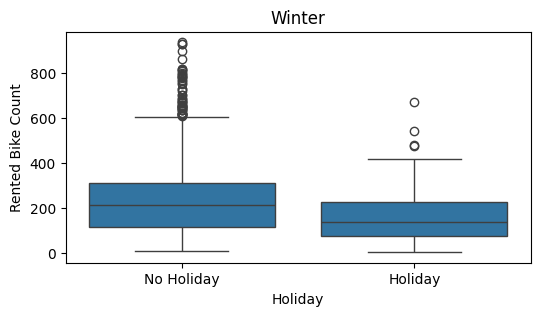

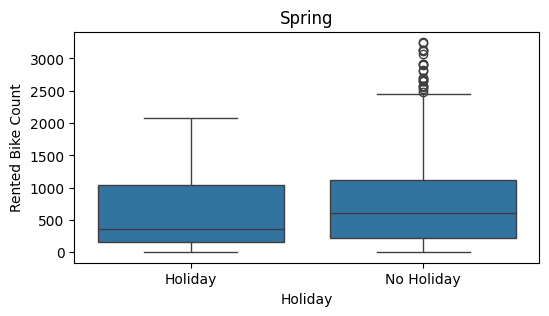

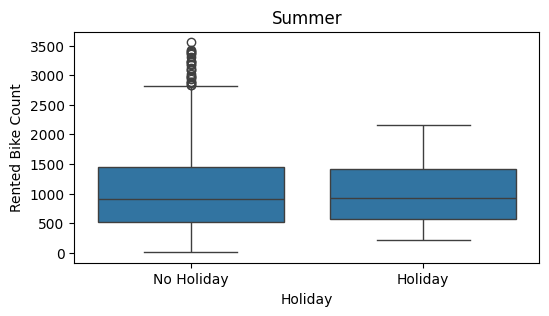

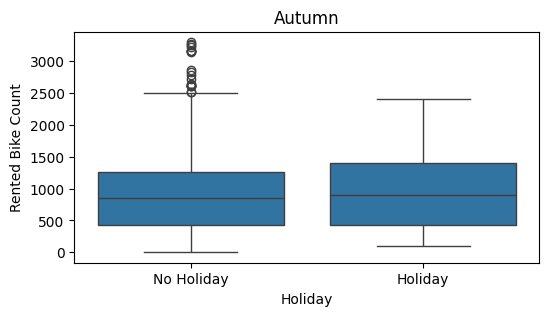

In [74]:
for season in df['Seasons'].unique():
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df[df['Seasons'] == f'{season}'], x='Holiday', y='Rented Bike Count')
    plt.title(season)
    plt.show()

Исходя из полученных графиков делаем вывод:
1. Зимой в праздники нагрузка на прокат в среднем снижается;  
2. Весной медианное значение в праздники выше, более того, видим значительные выбросы в сторону большого кол-ва арендованных велосипедов. Открытые источники говорят, что причина не в особых праздниках. В это время в городе проходят фестивали цветения, люди стремятся на живописные маршруты, особенно вдоль реки Ханган.Цветение сакуры происходит каждый год примерно в одно и то же время, что и создает стабильную, повторяющуюся из года в год волну повышенного спроса;  
3. Летом и осенью распределения очень схожи, можно сделать вывод что наличие праздника не играет значительной роли.

Как итог, 